In [1]:
using Pkg
Pkg.activate(@__DIR__)

using HDF5
using CSV
using DataFrames
using Korg

# Paths for the TiO ExoMol dataset and legacy Korg linelist
transition_file = "/home/way/KORG_grid/transitions/1H2-16O__POKAZATEL__06500-06600.trans"
states_file = "/home/way/KORG_grid/linelists/exomol/1H2-16O__POKAZATEL_v1.states"
broad_file_1 = "/home/way/Korg_ExoMol/1H2-16O__H2.broad"
broad_file_2 = "/home/way/Korg_ExoMol/1H2-16O__He.broad"
legacy_linelist = "/home/way/KORG_grid/sergeys_linelist.h5"

# Wavelength bounds for ExoMol loading (Å)
lower_wavelength = 15152.0
upper_wavelength = 15385.0

# Test temperature and pressures for absorption
temps = [2000.0, 3000.0]
n_e = [1e12, 1e13]
ξ = 2e5  # 2 km/s in cm/s

# Build a minimal density table for the test
n_densities = Dict(
    Korg.species"H_I" => [1e17, 1e16],
    Korg.species"He_I" => [1e16, 1e15],
    Korg.species"H2" => [1e16, 1e15],
    Korg.species"H2O" => [1e10, 1e10],
)

partition_fns = Dict(
    Korg.species"H2O" => Korg.default_partition_funcs[Korg.species"H2O"]
)

  Activating project at `~/Korg_ExoMol/Korg.jl`


Dict{Korg.Species, Korg.CubicSplines.CubicSpline{Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Float64}} with 1 entry:
  H2O => CubicSpline{Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{…

In [2]:
# legacy_lines = Korg.read_korg_linelist(legacy_linelist)
# println("Legacy linelist lines: ", length(legacy_lines))
# println("Sample legacy lines:")
# legacy_lines[1:min(end, 5)] |> display

# # Inspect broadening parameters for the first few lines
# legacy_samples = legacy_lines[1:min(end, 20)]
# legacy_broadening = DataFrame(
#     wl = [l.wl * 1e8 for l in legacy_samples],
#     log_gf = [l.log_gf for l in legacy_samples],
#     gamma_rad = [l.gamma_rad for l in legacy_samples],
#     gamma_stark = [l.gamma_stark for l in legacy_samples],
#     vdW = [l.vdW for l in legacy_samples],
#     gamma_mol_lorentz = [l.gamma_mol_lorentz for l in legacy_samples],
#     n_exp = [l.n_exp for l in legacy_samples],
# )
# legacy_broadening |> display

In [3]:
h2o_lines = Korg.load_ExoMol_linelist(Korg.species"H2O", states_file, transition_file,
                                        lower_wavelength, upper_wavelength;
                                        verbose=true,
                                        line_strength_cutoff=-15,
                                        T_line_strength=3500.0,
                                        path_flag=1,
                                        broad_files = (broad_file_1, broad_file_2),
                                        )
println("H2O ExoMol lines: ", length(h2o_lines))
println("Sample H2O lines:")
h2o_lines[1:min(end, 5)] |> display

# Inspect broadening parameters for TiO lines
sample_h2o = h2o_lines[1:min(end, 20)]
h2o_broadening = DataFrame(
    wl = [l.wl * 1e8 for l in sample_h2o],
    log_gf = [l.log_gf for l in sample_h2o],
    E_lower = [l.E_lower for l in sample_h2o],
    gamma_rad = [l.gamma_rad for l in sample_h2o],
    gamma_mol_lorentz = [l.gamma_mol_lorentz for l in sample_h2o],
    n_exp = [l.n_exp for l in sample_h2o],
)
h2o_broadening |> display

Loading ExoMol linelist from /home/way/KORG_grid/linelists/exomol/1H2-16O__POKAZATEL_v1.states and /home/way/KORG_grid/transitions/1H2-16O__POKAZATEL__06500-06600.trans. This functionality is experimental. Please report any issues.
Assuming the most abundant isotope for all atoms. Use the isotopes keyword argument to specify otherwise.
Removed 32881621 lines with strength below -15 at T = 3500.0 K out of 33880586 total lines (97%).
H2O ExoMol lines: 998965
Sample H2O lines:


5-element Vector{Korg.Line}:
 H2O 15152.00086 Å (log gf = -7.02, χ = 2.74 eV)
 H2O 15152.001147 Å (log gf = -7.56, χ = 1.95 eV)
 H2O 15152.001216 Å (log gf = -7.29, χ = 2.21 eV)
 H2O 15152.001391 Å (log gf = -6.48, χ = 2.91 eV)
 H2O 15152.001613 Å (log gf = -6.17, χ = 2.49 eV)

Row,wl,log_gf,E_lower,gamma_rad,gamma_mol_lorentz,n_exp
,Float64,Float64,Float64,Float64,Tuple…,Tuple…
1,15152.0,-7.02305,2.73864,2.75522,"(0.0248, 0.0055)","(0.136, 0.08)"
2,15152.0,-7.56267,1.94893,0.79531,"(0.033, 0.0086)","(0.239, 0.154)"
3,15152.0,-7.29164,2.21007,1.48443,"(0.0635, 0.0197)","(0.458, 0.252)"
4,15152.0,-6.47583,2.91447,9.71344,"(0.0344, 0.0091)","(0.248, 0.163)"
5,15152.0,-6.17303,2.49019,19.5064,"(0.0255, 0.0058)","(0.15, 0.09)"
6,15152.0,-7.15607,2.27937,2.02829,"(0.0225, 0.0047)","(0.081, 0.045)"
7,15152.0,-6.3257,3.32943,13.7246,"(0.0231, 0.0049)","(0.1, 0.055)"
8,15152.0,-7.10098,1.40786,2.30264,"(0.0558, 0.0169)","(0.4, 0.246)"
9,15152.0,-7.34686,1.88145,1.3072,"(0.0296, 0.0074)","(0.204, 0.13)"


In [19]:
sum([ismissing(line.gamma_mol_lorentz) for line in h2o_lines])/length(h2o_lines)

0.00020721446697331738

In [4]:
h2o_lines_legacy = Korg.load_ExoMol_linelist(Korg.species"H2O", states_file, transition_file,
                                        lower_wavelength, upper_wavelength;
                                        verbose=true,
                                        line_strength_cutoff=-15,
                                        T_line_strength=3500.0,
                                        path_flag=0,
                                        )
println("H2O ExoMol lines: ", length(h2o_lines_legacy))
println("Sample H2O lines:")
h2o_lines_legacy[1:min(end, 5)] |> display

# Inspect broadening parameters for TiO lines
sample_h2o_legacy = h2o_lines_legacy[1:min(end, 20)]
h2o_broadening_legacy = DataFrame(
    wl = [l.wl * 1e8 for l in sample_h2o_legacy],
    log_gf = [l.log_gf for l in sample_h2o_legacy],
    E_lower = [l.E_lower for l in sample_h2o_legacy],
    gamma_rad = [l.gamma_rad for l in sample_h2o_legacy],
    gamma_mol_lorentz = [l.gamma_mol_lorentz for l in sample_h2o_legacy],
    n_exp = [l.n_exp for l in sample_h2o_legacy],
)
h2o_broadening_legacy |> display

Loading ExoMol linelist from /home/way/KORG_grid/linelists/exomol/1H2-16O__POKAZATEL_v1.states and /home/way/KORG_grid/transitions/1H2-16O__POKAZATEL__06500-06600.trans. This functionality is experimental. Please report any issues.
Using default broadening (only radiative) for this species
Assuming the most abundant isotope for all atoms. Use the isotopes keyword argument to specify otherwise.
Removed 32881621 lines with strength below -15 at T = 3500.0 K out of 33880586 total lines (97%).
H2O ExoMol lines: 998965
Sample H2O lines:


5-element Vector{Korg.Line}:
 H2O 15152.00086 Å (log gf = -7.02, χ = 2.74 eV)
 H2O 15152.001147 Å (log gf = -7.56, χ = 1.95 eV)
 H2O 15152.001216 Å (log gf = -7.29, χ = 2.21 eV)
 H2O 15152.001391 Å (log gf = -6.48, χ = 2.91 eV)
 H2O 15152.001613 Å (log gf = -6.17, χ = 2.49 eV)

Row,wl,log_gf,E_lower,gamma_rad,gamma_mol_lorentz,n_exp
,Float64,Float64,Float64,Float64,Missing,Missing
1,15152.0,-7.02305,2.73864,2.75522,missing,missing
2,15152.0,-7.56267,1.94893,0.79531,missing,missing
3,15152.0,-7.29164,2.21007,1.48443,missing,missing
4,15152.0,-6.47583,2.91447,9.71344,missing,missing
5,15152.0,-6.17303,2.49019,19.5064,missing,missing
6,15152.0,-7.15607,2.27937,2.02829,missing,missing
7,15152.0,-6.3257,3.32943,13.7246,missing,missing
8,15152.0,-7.10098,1.40786,2.30264,missing,missing
9,15152.0,-7.34686,1.88145,1.3072,missing,missing


In [5]:
using PythonPlot

wls, flux, continuum = synth(
    Teff=3500, # effective temperature of 5000 Kelvin
    logg=5.0, # surface gravity of 10^(4.32) cm/s²
    M_H=0.5,  # metallicity, [M/H]. Overridden for individual elements by alpha_H and individual abundances
    #C=0.0,    # The Carbon abundance, [C/H].  Works for anything from He to U.
    linelist=h2o_lines,
    wavelengths=(lower_wavelength, upper_wavelength),
    R=5_000,
)

([15152.0, 15152.01, 15152.02, 15152.03, 15152.04, 15152.05, 15152.06, 15152.07, 15152.08, 15152.09  …  15384.91, 15384.92, 15384.93, 15384.94, 15384.95, 15384.96, 15384.97, 15384.98, 15384.99, 15385.0], [0.9530248063180485, 0.9529806086530106, 0.9529364101126658, 0.9528922134858414, 0.9528480219163757, 0.9528038388005812, 0.9527596677610285, 0.9527155124570639, 0.952671376597397, 0.9526272637667997  …  0.960499268223095, 0.9605788942104448, 0.960658414022588, 0.9607378261398649, 0.9608171291800793, 0.9608963218728376, 0.9609754030536635, 0.9610543716836694, 0.9611332268359584, 0.9612119675750188], [543956.142588076, 543955.8419959098, 543955.5414419436, 543955.2408201226, 543954.9402585191, 543954.6396269746, 543954.3390743654, 543954.0384604121, 543953.7379360757, 543953.4373240853  …  537242.0589548773, 537241.7878987439, 537241.5168359157, 537241.245798294, 537240.974780181, 537240.7037007682, 537240.4326789691, 537240.1616057521, 537239.8905881176, 537239.619573955])

In [6]:
wls_legacy, flux_legacy, continuum_legacy = synth(
    Teff=3500, # effective temperature of 5000 Kelvin
    logg=5.0, # surface gravity of 10^(4.32) cm/s²
    M_H=0.5,  # metallicity, [M/H]. Overridden for individual elements by alpha_H and individual abundances
    #C=0.0,    # The Carbon abundance, [C/H].  Works for anything from He to U.
    linelist=h2o_lines_legacy,
    wavelengths=(lower_wavelength, upper_wavelength),
    R=5_000
)

([15152.0, 15152.01, 15152.02, 15152.03, 15152.04, 15152.05, 15152.06, 15152.07, 15152.08, 15152.09  …  15384.91, 15384.92, 15384.93, 15384.94, 15384.95, 15384.96, 15384.97, 15384.98, 15384.99, 15385.0], [0.9529587923530135, 0.9529145977034241, 0.9528704021420378, 0.9528262084592233, 0.9527820198349275, 0.9527378396749883, 0.9526936716223686, 0.9526495193745876, 0.9526053866526016, 0.9525612770707678  …  0.9604474622897268, 0.9605271872520361, 0.96060680612207, 0.9606863173829165, 0.9607657196319792, 0.9608450116053832, 0.960924192122179, 0.9610032601611691, 0.9610822147838114, 0.9611610550743414], [543956.142588076, 543955.8419959098, 543955.5414419436, 543955.2408201226, 543954.9402585191, 543954.6396269746, 543954.3390743654, 543954.0384604121, 543953.7379360757, 543953.4373240853  …  537242.0589548773, 537241.7878987439, 537241.5168359157, 537241.245798294, 537240.974780181, 537240.7037007682, 537240.4326789691, 537240.1616057521, 537239.8905881176, 537239.619573955])

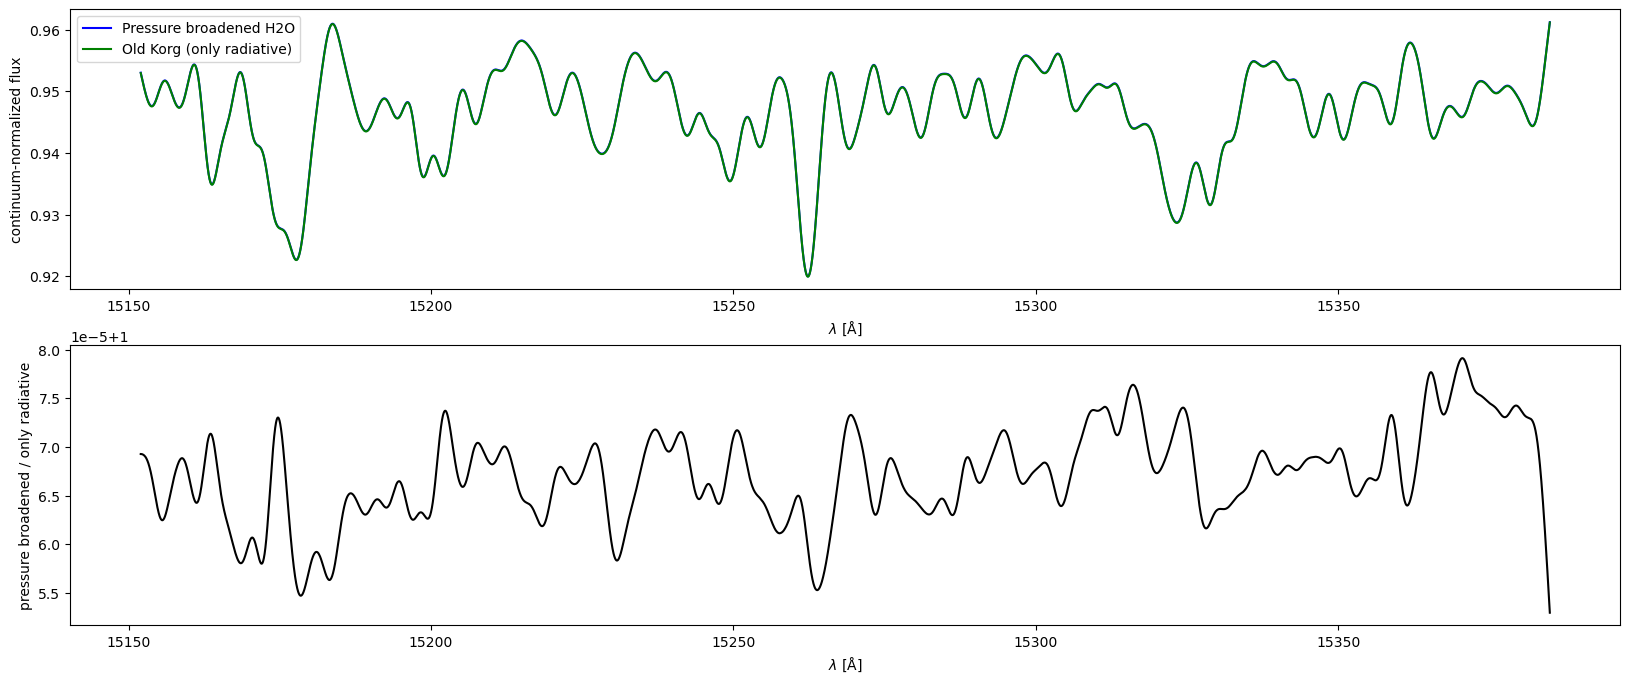

In [11]:
figure(figsize=(20, 8))
subplot(211)
plot(wls, flux, color="b", label="Pressure broadened H2O")
plot(wls_legacy, flux_legacy, color="g", label="Old Korg (only radiative)")
legend()
#ylim(0,1.2)
xlabel(L"$\lambda$ [Å]")
ylabel("continuum-normalized flux")

subplot(212)
plot(wls, flux./flux_legacy, color="k")
xlabel(L"$\lambda$ [Å]")
ylabel("pressure broadened / only radiative")

display(gcf())

In [25]:
log10_teffs = [log10(Teff) for Teff in Korg._sdss_marcs_atmospheres[1][1]][1:5]
el_ = @elapsed H2O_MCS = Korg.MolecularCrossSection(h2o_lines, (lower_wavelength, upper_wavelength); vmic_vals=[0.31622777, 5.], log_temp_vals=log10_teffs)
println(el_)

Korg.save_molecular_cross_section("../foobar_H2O.h5", H2O_MCS)

3.514153533


In [32]:
A_X = format_A_X(0.5)
atm = Korg.interpolate_marcs(3500, 5.0, A_X)

wls_, flux_, continuum_ = synthesize(
    atm,
    h2o_lines_legacy[1:5],
    A_X,
    (lower_wavelength, upper_wavelength),
    molecular_cross_sections= [H2O_MCS]
    #R=5_000,
    #synthesize_kwargs = ()
)

MethodError: MethodError: no method matching iterate(::Korg.SynthesisResult)
The function `iterate` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  iterate(!Matched::Base.Iterators.ProductIterator{Tuple{}})
   @ Base iterators.jl:1122
  iterate(!Matched::Base.Iterators.ProductIterator{Tuple{}}, !Matched::Any)
   @ Base iterators.jl:1123
  iterate(!Matched::HDF5.AttributeDict)
   @ HDF5 ~/.julia/packages/HDF5/8g5ny/src/attributes.jl:349
  ...


In [45]:
H2O_MCS.itp

2×5×23301 extrapolate(interpolate((::Vector{Float64},::Vector{Float32},::Korg.Wavelengths{Float64, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}), ::Array{Float64, 3}, (Gridded(Linear()), Gridded(Linear()), Gridded(Linear()))), 0.0) with element type Float64:
[:, :, 1] =
 3.00052e-31  6.12911e-31  1.18744e-30  2.19325e-30  3.87975e-30
 1.47037e-28  2.33189e-28  3.56728e-28  5.28286e-28  7.59752e-28

[:, :, 2] =
 5.89068e-31  1.1766e-30   2.23219e-30  4.04261e-30  7.02021e-30
 1.5721e-28   2.49256e-28  3.8121e-28   5.644e-28    8.11489e-28

[:, :, 3] =
 1.12323e-30  2.1959e-30   4.08317e-30  7.25694e-30  1.23812e-29
 1.67639e-28  2.65721e-28  4.06288e-28  6.01381e-28  8.64451e-28

;;; … 

[:, :, 23299] =
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0

[:, :, 23300] =
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0

[:, :, 23301] =
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0

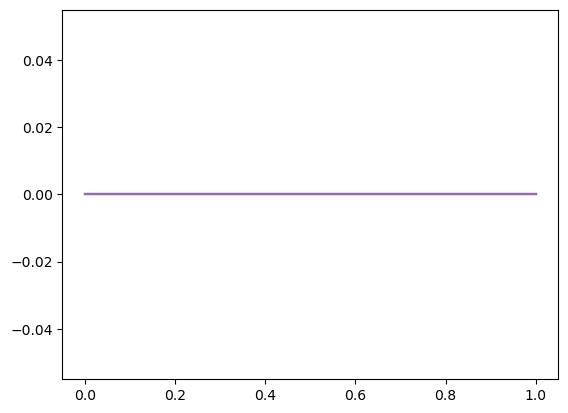

In [47]:
figure()
plot(H2O_MCS.itp[:,:,3])
display(gcf())

In [ ]:
wls, itp, species